In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, interpolate, integrate, optimize

https://stackoverflow.com/questions/79873891/scipy-optimize-minimize-for-scipy-integrate-solve-ivp-results-in-success-false/79877318#79877318

In [2]:
n = 15

In [3]:
tobs = np.linspace(0, 10, n)

In [4]:
distribution = stats.gamma(a=3.7, scale=1.5, loc=-1.5)

In [5]:
fobs = 0.5 * distribution.pdf(tobs) + 0.10

In [6]:
tlin = np.linspace(tobs.min(), tobs.max(), 200)
interpolator = interpolate.interp1d(tobs, fobs, kind="cubic", fill_value="extrapolate")

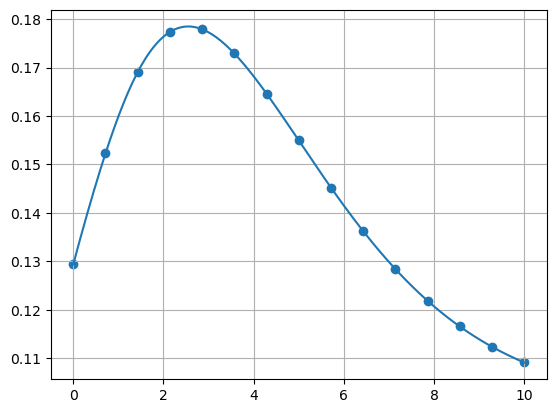

In [7]:
fig, axe = plt.subplots()
axe.scatter(tobs, fobs)
axe.plot(tlin, interpolator(tlin))
axe.grid()

In [8]:
def model(t, B, r, K, function):
    return r * B * (1. - B / K) - function(t) * B

In [9]:
def solver(parameters, t, function):
    return integrate.solve_ivp(model, (t[0], t[-1]), y0=[parameters[-1]], args=(*parameters[:-1], function), t_eval=t)

In [10]:
def objective(parameters, t, B, function):
    solution = solver(parameters, t, function)
    return np.sum(np.power((solution.y - B), 2)) / B.size

In [11]:
p0 = (1.2345e-1, 9.876e5, 7.654e3)
p0

(0.12345, 987600.0, 7654.0)

In [12]:
solution = solver(p0, tobs, interpolator)

In [13]:
np.random.seed(12345)

In [14]:
Bref = solution.y
Bobs = Bref + 25. * np.random.normal(size=Bref.size)

In [15]:
result = optimize.minimize(
    fun=objective,
    x0=(1e-1, 1e5, 1e4),
    method="powell",
    args=(tobs, Bobs, interpolator),
    tol=1e-8,
)
result

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 1
     fun: 434.28614024318324
       x: [ 1.231e-01  5.934e+06  7.654e+03]
     nit: 57
   direc: [[-5.593e-04  9.678e+03  3.584e+00]
           [-1.304e-04  1.038e+05 -4.144e-01]
           [-6.405e-05  1.298e+06  2.235e-01]]
    nfev: 3000

In [16]:
estimate = solver(result.x, tlin, interpolator)
estimate

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.025e-02 ...  9.950e+00  1.000e+01]
        y: [[ 7.654e+03  7.651e+03 ...  6.040e+03  6.044e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 26
     njev: 0
      nlu: 0

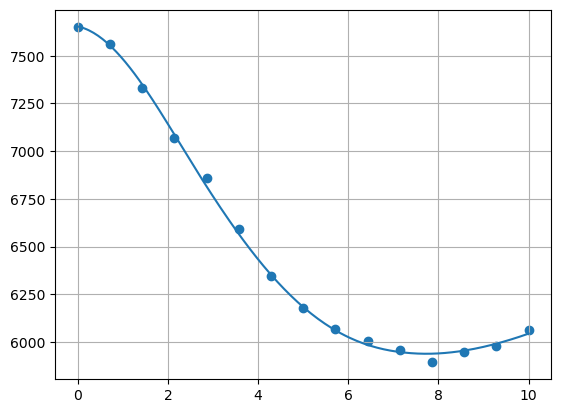

In [17]:
fig, axe = plt.subplots()
axe.scatter(tobs, Bobs)
axe.plot(tlin, estimate.y.T)
axe.grid()

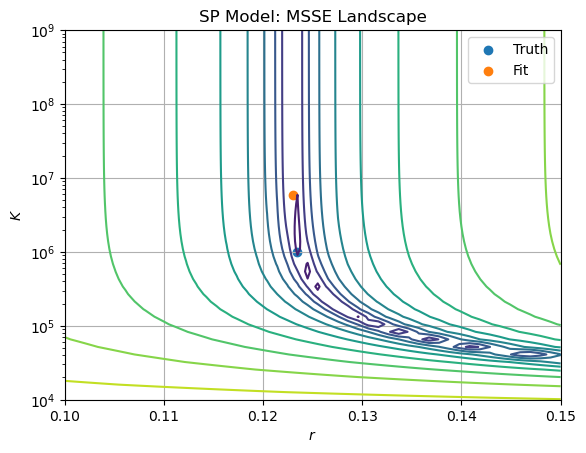

In [18]:
rlin = np.linspace(0.1, 0.15, 50)
Klin = np.logspace(4, 9, 50, base=10)
r, K = np.meshgrid(rlin, Klin)

def landscape_factory(t, B, function, result):
    @np.vectorize
    def wrapped(r, K):
        return objective((r, K, result.x[-1]), t, B, function)
    return wrapped

landscape = landscape_factory(tobs, Bobs, interpolator, result)
loss = landscape(r, K)

fig, axe = plt.subplots()
axe.contour(r, K, np.log10(loss), levels=10)
axe.set_title("SP Model: MSSE Landscape")
axe.set_xlabel("$r$")
axe.set_ylabel("$K$")
axe.scatter(*p0[:2], label="Truth")
axe.scatter(*result.x[:2], label="Fit")
axe.set_yscale("log")
axe.legend()
axe.grid() 